# FD001 exploration

Exploration only. Nothing in the pipeline depends on this notebook; the decisions it produces are
recorded in `DriftWatch-Guide.md` (Phase 1, step 3) and implemented in `data/features.py`.

**Scope guard:** this notebook reads FD001 and nothing else. FD002 and FD004 are quarantined as
"production" replay traffic for the drift phase, and FD003 is unused. Every file path below is
derived from the single `SUBSET` constant.

Questions to answer:

1. What does one engine's life look like, and how long do engines last?
2. Do the operating settings carry any signal in FD001?
3. Which sensors are informative, and which are dead weight?
4. How many cycles before failure does degradation become visible? That decides the label horizon N.
5. How large can the rolling window k be without losing engines?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SUBSET = "FD001"
assert SUBSET == "FD001", "Only FD001 may be explored before Phase 5"

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists())
RAW = ROOT / "data" / "raw"

COLS = ["unit", "cycle", "setting_1", "setting_2", "setting_3"] + [f"s_{i}" for i in range(1, 22)]
SETTINGS = ["setting_1", "setting_2", "setting_3"]
SENSORS = [c for c in COLS if c.startswith("s_")]


def load(kind: str) -> pd.DataFrame:
    # C-MAPSS files are space separated with trailing whitespace, hence the regex separator.
    return pd.read_csv(RAW / f"{kind}_{SUBSET}.txt", sep=r"\s+", header=None, names=COLS)


train = load("train")
test = load("test")
rul_at_end = pd.read_csv(RAW / f"RUL_{SUBSET}.txt", header=None, names=["rul_at_end"])
rul_at_end.index = rul_at_end.index + 1  # unit numbers are 1-based

pd.set_option("display.width", 160)
print(f"train: {train.shape[0]:,} rows, {train.unit.nunique()} engines, {int(train.isna().sum().sum())} nulls")
print(f"test:  {test.shape[0]:,} rows, {test.unit.nunique()} engines, {len(rul_at_end)} RUL values")
contiguous = train.groupby("unit").cycle.apply(lambda s: (s.diff().dropna() == 1).all()).all()
print(f"cycles contiguous within every engine: {bool(contiguous)}")

train: 20,631 rows, 100 engines, 0 nulls
test:  13,096 rows, 100 engines, 100 RUL values
cycles contiguous within every engine: True


## 1. Engine lifetimes

Every training engine runs from healthy to failure, so the last cycle of each unit is its total life.
The test engines are cut off before failure and `RUL_FD001.txt` gives the true remaining life at the cut.

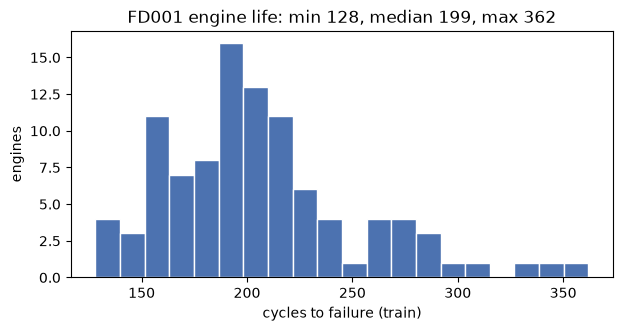

,train life,test cycles observed,test RUL at cut
count,100.0,100.0,100.0
mean,206.3,131.0,75.5
std,46.3,53.6,41.8
min,128.0,31.0,7.0
25%,177.0,88.8,32.8
50%,199.0,133.5,86.0
75%,229.2,164.2,112.2
max,362.0,303.0,145.0


In [2]:
life = train.groupby("unit").cycle.max().rename("cycles_to_failure")
train["rul"] = train.groupby("unit").cycle.transform("max") - train.cycle

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(life, bins=20, color="#4C72B0", edgecolor="white")
ax.set_xlabel("cycles to failure (train)")
ax.set_ylabel("engines")
ax.set_title(f"FD001 engine life: min {life.min()}, median {int(life.median())}, max {life.max()}")
plt.show()

pd.DataFrame({"train life": life.describe(), "test cycles observed": test.groupby("unit").cycle.max().describe(),
              "test RUL at cut": rul_at_end.rul_at_end.describe()}).round(1)

Lifetimes range from 128 to 362 cycles with a median near 200. The shortest life bounds every later
choice: the label horizon N plus the rolling window k must fit comfortably inside 128 cycles.
The test engines are observed for as few as 31 cycles, which matters for k (section 5).

## 2. Operating settings

FD001 is documented as a single operating condition. Confirm that the three settings are constant,
because if they are, they contribute nothing to the model here. They still get logged at serving time:
when FD002 replays with six regimes in Phase 5, the settings are the clearest drift fingerprint.

In [3]:
pd.DataFrame({"std": train[SETTINGS].std(), "min": train[SETTINGS].min(), "max": train[SETTINGS].max(),
              "unique values": train[SETTINGS].nunique()}).round(5)

,std,min,max,unique values
setting_1,0.00219,-0.0087,0.0087,158
setting_2,0.00029,-0.0006,0.0006,13
setting_3,0.00000,100.0000,100.0000,1


`setting_3` is a constant and the other two vary by less than a hundredth around zero (sensor noise).
**Decision: settings are excluded from model features but kept in the raw prediction log.**

## 3. Sensor screening

Two questions per sensor: does it vary at all, and does it track remaining life? The second is measured
with Spearman correlation against RUL, which catches monotonic trends regardless of scale.

In [4]:
screen = pd.DataFrame({
    "std": train[SENSORS].std(),
    "unique values": train[SENSORS].nunique(),
    "spearman_vs_rul": train[SENSORS + ["rul"]].corr(method="spearman")["rul"].drop("rul"),
})
screen["drop"] = screen["unique values"] <= 2
screen.round(3).sort_values("spearman_vs_rul")

,std,unique values,spearman_vs_rul,drop
s_11,0.267,159,-0.718,False
s_4,9.001,4051,-0.702,False
s_15,0.038,1918,-0.666,False
s_2,0.500,310,-0.629,False
s_17,1.549,13,-0.629,False
s_3,6.131,3012,-0.606,False
s_8,0.071,53,-0.574,False
s_13,0.072,56,-0.573,False
s_9,22.083,6403,-0.322,False
s_14,19.076,6078,-0.202,False


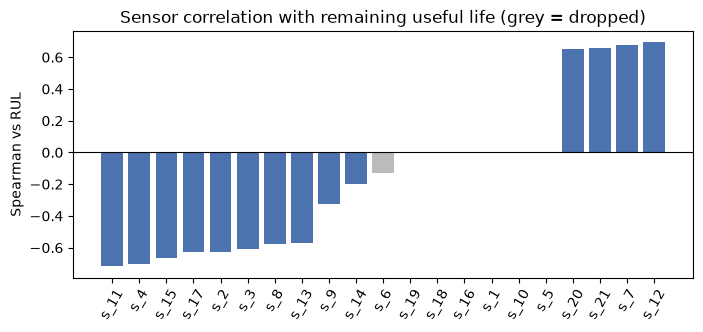

drop: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
keep: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.2))
corr = screen["spearman_vs_rul"].fillna(0).sort_values()
ax.bar(corr.index, corr.values, color=np.where(screen.loc[corr.index, "drop"], "#BBBBBB", "#4C72B0"))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Spearman vs RUL")
ax.set_title("Sensor correlation with remaining useful life (grey = dropped)")
ax.tick_params(axis="x", rotation=60)
plt.show()

DROP_SENSORS = screen.index[screen["drop"]].tolist()
KEEP_SENSORS = [s for s in SENSORS if s not in DROP_SENSORS]
print("drop:", DROP_SENSORS)
print("keep:", KEEP_SENSORS)

Six sensors never change (`s_1`, `s_5`, `s_10`, `s_16`, `s_18`, `s_19`) and `s_6` flips between two values
with no relationship to RUL. `s_8` and `s_13` barely move in absolute terms, yet both track RUL at
roughly -0.57, so variance alone would have been the wrong filter.

**Decision: drop any sensor with two or fewer distinct values. That removes seven and keeps fourteen.**
The rule is simple enough to re-apply in `features.py` rather than hardcoding a list.

## 4. When does degradation become visible?

This is the evidence for the label horizon. Two views: a few individual engines against the fleet
average, and a table of how far each sensor's band mean sits from its healthy baseline
(more than 120 cycles from failure), in units of that baseline's standard deviation.

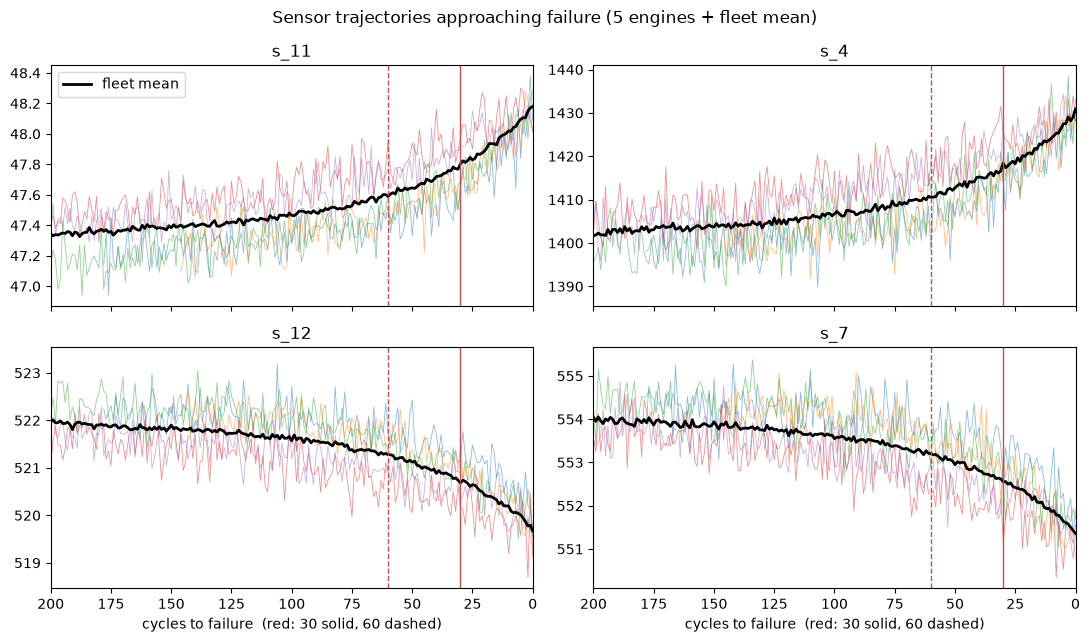

In [6]:
SHOW = ["s_11", "s_4", "s_12", "s_7"]
SAMPLE_UNITS = [3, 24, 47, 69, 92]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True)
fleet = train[train.rul <= 200].groupby("rul")[SHOW].mean()
for ax, sensor in zip(axes.ravel(), SHOW):
    for unit in SAMPLE_UNITS:
        u = train[train.unit == unit]
        ax.plot(u.rul, u[sensor], linewidth=0.6, alpha=0.5)
    ax.plot(fleet.index, fleet[sensor], color="black", linewidth=2, label="fleet mean")
    for n, style in ((30, "-"), (60, "--")):
        ax.axvline(n, color="#C44E52", linestyle=style, linewidth=1)
    ax.set_title(sensor)
    ax.set_xlim(200, 0)
axes[0, 0].legend(loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("cycles to failure  (red: 30 solid, 60 dashed)")
fig.suptitle("Sensor trajectories approaching failure (5 engines + fleet mean)")
fig.tight_layout()
plt.show()

In [7]:
baseline = train[train.rul > 120][KEEP_SENSORS]
mu, sd = baseline.mean(), baseline.std()
bands = [(0, 10), (10, 20), (20, 30), (30, 45), (45, 60), (60, 80), (80, 100), (100, 120)]
rows = {}
for lo, hi in bands:
    band = train[(train.rul >= lo) & (train.rul < hi)][KEEP_SENSORS]
    rows[f"{lo}-{hi}"] = ((band.mean() - mu) / sd).abs()
zshift = pd.DataFrame(rows).T
zshift.index.name = "cycles to failure"
top = screen.loc[KEEP_SENSORS, "spearman_vs_rul"].abs().sort_values(ascending=False).index[:8]
zshift[top].round(2)

,s_11,s_4,s_12,s_7,s_15,s_21,s_20,s_17
cycles to failure,,,,,,,,
0-10,4.22,4.08,3.91,3.71,3.61,3.44,3.47,3.26
10-20,3.43,3.26,3.17,3.02,2.95,2.80,2.75,2.65
20-30,2.76,2.66,2.55,2.42,2.33,2.26,2.25,2.14
30-45,2.13,2.08,2.02,1.91,1.80,1.74,1.77,1.64
45-60,1.57,1.52,1.47,1.40,1.36,1.29,1.31,1.25
60-80,1.09,1.05,1.02,0.98,0.95,0.90,0.89,0.83
80-100,0.73,0.69,0.63,0.63,0.57,0.58,0.60,0.55
100-120,0.46,0.46,0.43,0.41,0.34,0.37,0.36,0.35


Reading the table: inside the last 30 cycles the best sensors sit two to four standard deviations away
from healthy behaviour, which is unambiguous. Between 30 and 60 cycles the shift is one and a half to
two, still separable. Past 60 it drops under one and the trend blends into noise by 100.

So a positive label that begins 30 cycles out is one the sensors can actually support. A horizon of 60
would ask the model to flag engines where the signal is barely above noise, and 15 would waste the
clearest part of the curve.

## 5. Label horizon N and rolling window k

The target is binary: `label = 1` when the engine fails within the next N cycles. Because every
training engine runs to failure, each contributes exactly N + 1 positive rows, so the positive rate
is set by the lifetime distribution.

In [8]:
balance = []
for n in (15, 20, 30, 45, 60):
    y = train.rul <= n
    balance.append({"N": n, "positive rate": round(y.mean(), 3), "positives": int(y.sum()),
                    "positives per engine": int(y.groupby(train.unit).sum().iloc[0])})
pd.DataFrame(balance).set_index("N")

,positive rate,positives,positives per engine
N,,,
15,0.078,1600,16
20,0.102,2100,21
30,0.150,3100,31
45,0.223,4600,46
60,0.296,6100,61


In [9]:
min_test_cycles = int(test.groupby("unit").cycle.max().min())
window = []
for k in (10, 20, 30, 40):
    usable = life - k + 1
    window.append({"k": k, "min usable rows per train engine": int(usable.min()),
                   "train engines losing labels": int((usable < 31).sum()),
                   "test engines shorter than k": int((test.groupby("unit").cycle.max() < k).sum())})
print(f"shortest observed test engine: {min_test_cycles} cycles")
pd.DataFrame(window).set_index("k")

shortest observed test engine: 31 cycles


,min usable rows per train engine,train engines losing labels,test engines shorter than k
k,,,
10,119,0,0
20,109,0,0
30,99,0,0
40,89,0,4


**Decision: N = 30.** Positive rate is 15%, every engine contributes 31 positives, and the sensors are
clearly separated from baseline across the whole positive region (section 4). This confirms the
N = 30 default in the build plan.

**Decision: k = 20.** Any k up to 40 keeps every training engine, so the binding constraint is serving.
`/predict` receives the last k raw cycles of one engine, and the shortest FD001 test engine is
observed for only 31 cycles. k = 20 scores every test engine with headroom to spare and keeps the
request payload small. Larger windows smooth more but were not needed to see the trend.

## 6. The official test split

`test_FD001.txt` stops each engine early and `RUL_FD001.txt` gives the remaining life at that cut,
so RUL is derivable at every test row, not just the last one. That makes the official split a
usable second holdout with new engines, which is the realistic serving scenario. It is not the
primary evaluation: the plan splits training engines by unit (never by row), and the challenger vs
champion judgement in Phase 5 uses that split plus the replayed regime.

In [10]:
test = test.merge(rul_at_end, left_on="unit", right_index=True)
test["rul"] = test.rul_at_end + (test.groupby("unit").cycle.transform("max") - test.cycle)
y_test = test.rul <= 30
print(f"official test rows: {len(test):,}, positive rate at N=30: {y_test.mean():.3f}, "
      f"engines with any positive: {int(y_test.groupby(test.unit).any().sum())} of {test.unit.nunique()}")

official test rows: 13,096, positive rate at N=30: 0.025, engines with any positive: 25 of 100


## Decisions carried forward

| Decision | Value | Evidence |
|---|---|---|
| Label horizon N | 30 cycles | Sensors 2 to 4 SD from baseline inside 30 cycles; 15% positive rate |
| Sensors dropped | any with 2 or fewer distinct values (7 of 21) | Section 3 |
| Sensors kept | 14 | Section 3 |
| Operating settings | excluded from features, kept in the raw log | constant in FD001, drift fingerprint later |
| Rolling window k | 20 cycles | shortest test engine is 31 cycles; no train engine loses labels |
| Split | by engine unit, never by row | rows within an engine are correlated |
| Official test set | optional second holdout | RUL derivable at every row |
| FD002 / FD003 / FD004 | untouched | scope guard at the top of this notebook |

In [11]:
DECISIONS = {
    "label_horizon_cycles": 30,
    "window_cycles": 20,
    "drop_rule": "sensor has <= 2 distinct values in FD001 train",
    "dropped_sensors": DROP_SENSORS,
    "kept_sensors": KEEP_SENSORS,
    "settings_as_features": False,
    "split": "by engine unit",
}
DECISIONS

{'label_horizon_cycles': 30,
 'window_cycles': 20,
 'drop_rule': 'sensor has <= 2 distinct values in FD001 train',
 'dropped_sensors': ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19'],
 'kept_sensors': ['s_2',
  's_3',
  's_4',
  's_7',
  's_8',
  's_9',
  's_11',
  's_12',
  's_13',
  's_14',
  's_15',
  's_17',
  's_20',
  's_21'],
 'settings_as_features': False,
 'split': 'by engine unit'}